# Project for Data Analytics 3360-001
Team Members:
- Ahmed Bofateim - 300418113
- Toby Nosa-Omoregie - 300404378
- Trong Nghia Le - 300399881
- Isaac Rangel - 300410730



# Loading python libraries

In [1]:
# Loading the Necessary python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,RobustScaler

from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

# Reading the Cleaned DataSet 

In [2]:
# Making sure that we have the data set file in the same folder, then read the dataset

df = pd.read_csv('Exam_Score_Cleaned_Final.csv')

# Now we can check the content of the dataset
df.head()

,Age,Gender,Course,InternetAccess,SleepQuality,StudyMethod,FacilityRating,ExamDifficulty,Grade,StudyLevel,SleepLevel,AttendanceLevel
0,17,male,diploma,yes,poor,coaching,low,hard,D,medium,good,high
1,23,other,bca,yes,average,online,medium,moderate,D,medium,bad,medium
2,22,male,bsc,yes,poor,coaching,high,moderate,A,high,good,medium
3,20,other,diploma,yes,average,online,low,moderate,F,low,regular,low
4,20,female,diploma,yes,poor,coaching,low,moderate,F,low,good,medium


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              20000 non-null  int64 
 1   Gender           20000 non-null  object
 2   Course           20000 non-null  object
 3   InternetAccess   20000 non-null  object
 4   SleepQuality     20000 non-null  object
 5   StudyMethod      20000 non-null  object
 6   FacilityRating   20000 non-null  object
 7   ExamDifficulty   20000 non-null  object
 8   Grade            20000 non-null  object
 9   StudyLevel       20000 non-null  object
 10  SleepLevel       20000 non-null  object
 11  AttendanceLevel  20000 non-null  object
dtypes: int64(1), object(11)
memory usage: 1.8+ MB


In [4]:
# Getting some statistical data from the df

df.describe()

,Age
count,20000.000000
mean,20.473300
std,2.284458
min,17.000000
25%,18.000000
50%,20.000000
75%,22.000000
max,24.000000


# Univarariate Analysis of some columns

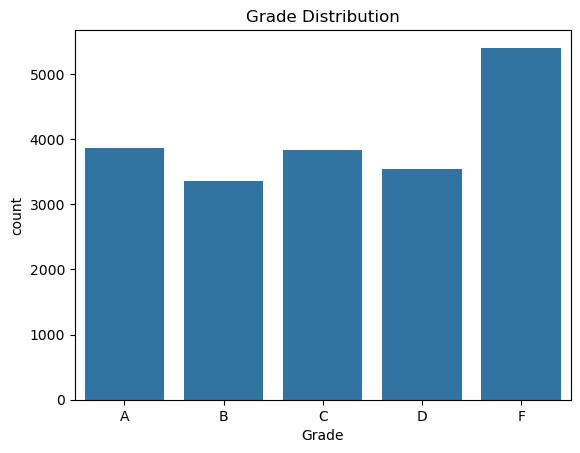

In [5]:
# Grade distribution plot
grade_order = ['A', 'B', 'C', 'D', 'F']

sns.countplot(x='Grade', data=df, order=grade_order)
plt.title('Grade Distribution')
plt.show()

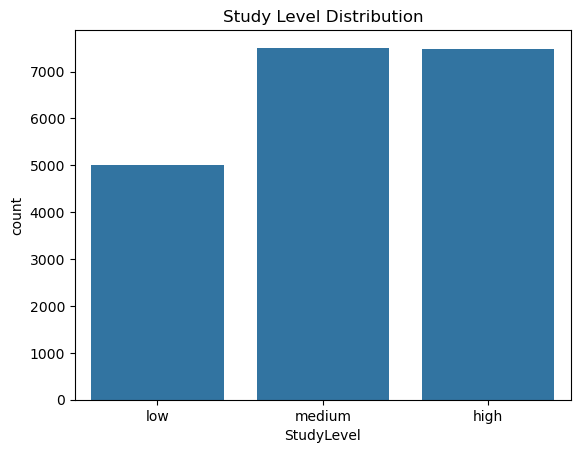

In [6]:
# StudyLevel Distribution plot 
order = ['low', 'medium', 'high']
sns.countplot(x='StudyLevel', data=df, order=order)
plt.title('Study Level Distribution')
plt.show()

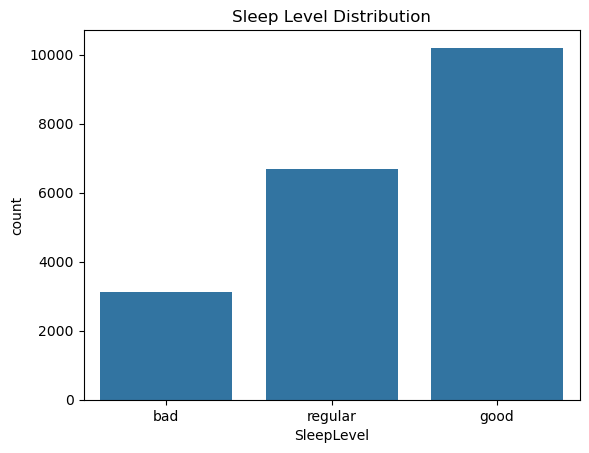

In [7]:
# SleepLevel plot
sns.countplot(x='SleepLevel', data=df, order=['bad','regular','good'])
plt.title('Sleep Level Distribution')
plt.show()

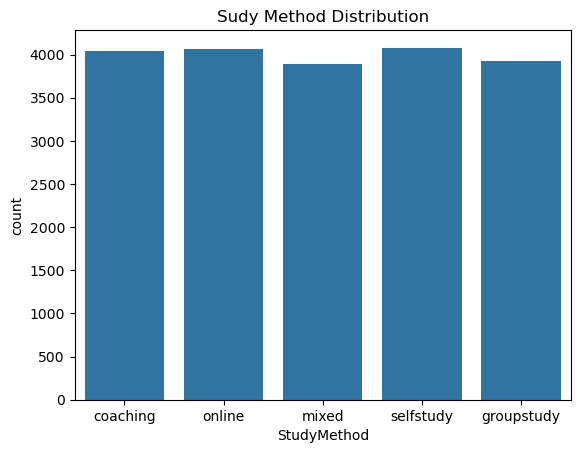

In [8]:
# StudyMethod plot
sns.countplot(x='StudyMethod', data=df)
plt.title('Sudy Method Distribution')
plt.show()

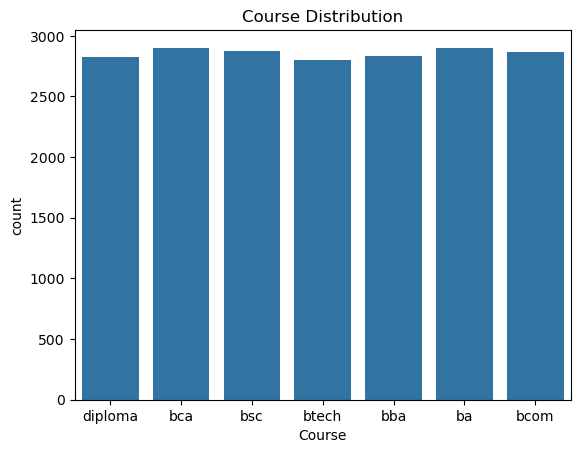

In [9]:
# Course plot
sns.countplot(x='Course', data=df)
plt.title('Course Distribution')
plt.show()

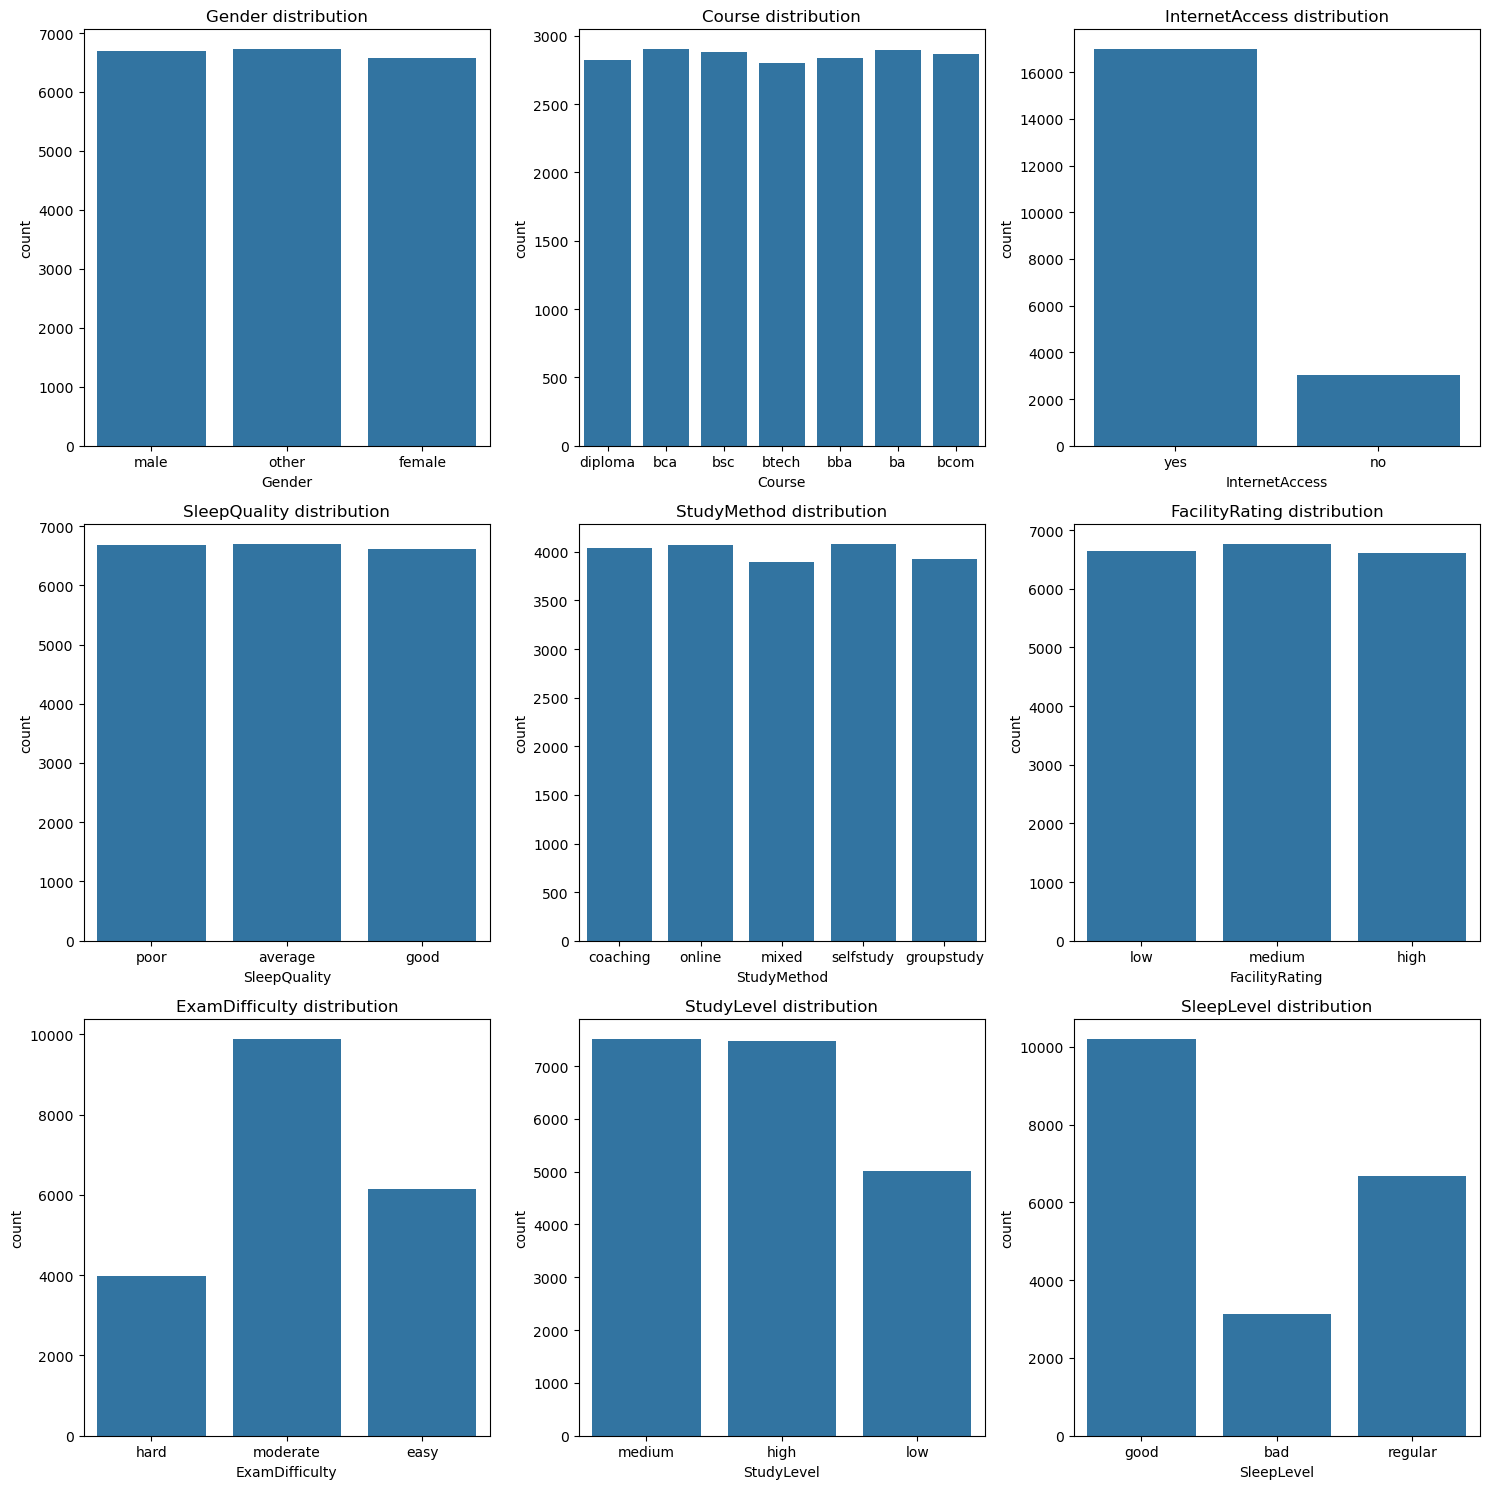

In [10]:
# List of features to plot
features = [
    'Gender', 'Course', 'InternetAccess', 'SleepQuality', 
    'StudyMethod', 'FacilityRating', 'ExamDifficulty', 
    'StudyLevel', 'SleepLevel'
]

# Determine number of rows and columns for the grid
n_features = len(features)
cols = 3  # number of plots per row
rows = n_features // cols + int(n_features % cols != 0)

# Create figure
fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten()  # flatten in case rows*cols > n_features

# Loop through each feature
for i, feature in enumerate(features):
    if df[feature].dtype.name == 'category' or df[feature].dtype == object:
        sns.countplot(x=feature, data=df, ax=axes[i])
        axes[i].set_title(f'{feature} distribution')
        axes[i].tick_params(axis='x', rotation=0)
    else:  # numeric
        sns.histplot(df[feature], kde=True, ax=axes[i])
        axes[i].set_title(f'{feature} distribution')

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Multivariate Analysis

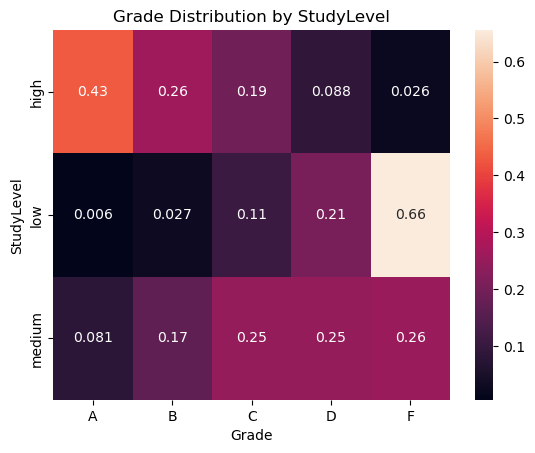

In [11]:
# Study Level vs Grade
grade_order = ['A','B','C','D','F']

cross = pd.crosstab(df['StudyLevel'], df['Grade'], normalize='index')
cross = cross[grade_order]

sns.heatmap(cross, annot=True)
plt.title('Grade Distribution by StudyLevel')
plt.show()

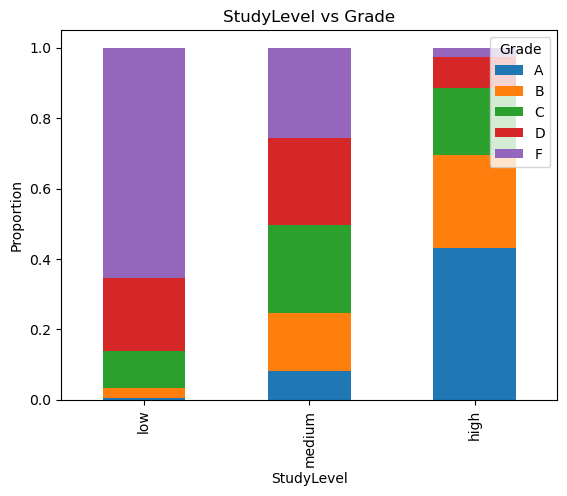

In [12]:
# StudyLevel and Grade
cross = pd.crosstab(df['StudyLevel'], df['Grade'], normalize='index')
cross = cross.reindex(['low','medium','high'])
cross = cross[grade_order]

cross.plot(kind='bar', stacked=True)
plt.title('StudyLevel vs Grade')
plt.ylabel('Proportion')
plt.legend(title='Grade', loc='upper right')
plt.show()

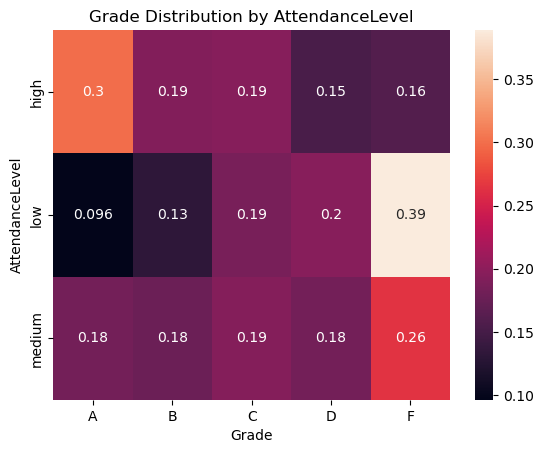

In [13]:
# AttendanceLevel vs Grade
cross = pd.crosstab(df['AttendanceLevel'], df['Grade'], normalize='index')
cross = cross[grade_order]

sns.heatmap(cross, annot=True)
plt.title('Grade Distribution by AttendanceLevel')
plt.show()

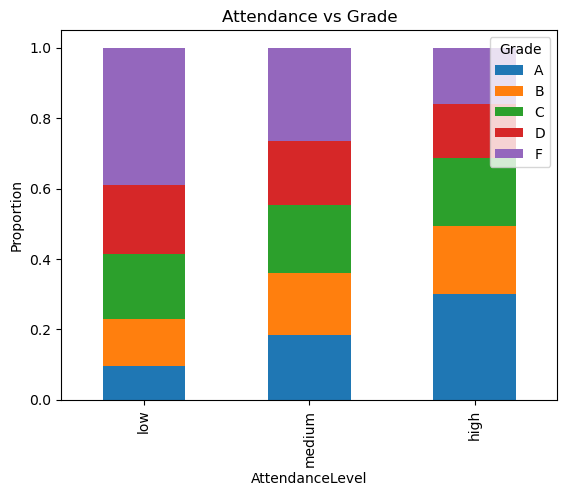

In [14]:
# Attendance and Grade
cross = pd.crosstab(df['AttendanceLevel'], df['Grade'], normalize='index')
cross = cross.reindex(['low','medium','high'])
cross = cross[grade_order]

cross.plot(kind='bar', stacked=True)
plt.title('Attendance vs Grade')
plt.ylabel('Proportion')
plt.legend(title='Grade', loc='upper right')
plt.show()

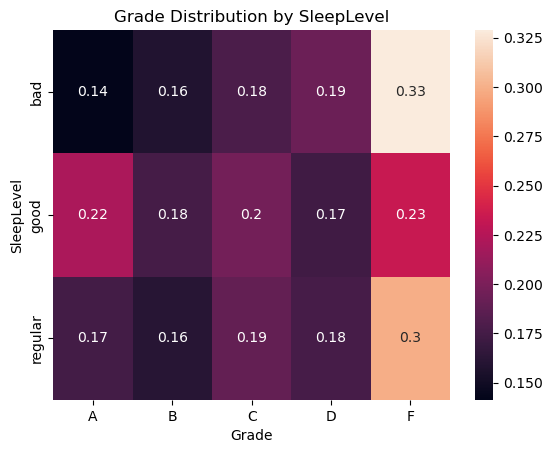

In [15]:
# Sleep Level 
cross = pd.crosstab(df['SleepLevel'], df['Grade'], normalize='index')
cross = cross[grade_order]

sns.heatmap(cross, annot=True)
plt.title('Grade Distribution by SleepLevel')
plt.show()

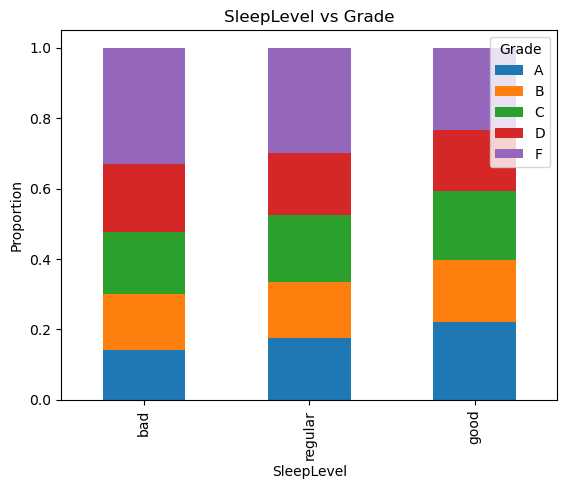

In [16]:
# SleepLevel and Grade
cross = pd.crosstab(df['SleepLevel'], df['Grade'], normalize='index')
cross = cross.reindex(['bad','regular','good'])
cross = cross[grade_order]

cross.plot(kind='bar', stacked=True)
plt.title('SleepLevel vs Grade')
plt.ylabel('Proportion')
plt.legend(title='Grade', loc='upper right')
plt.show()

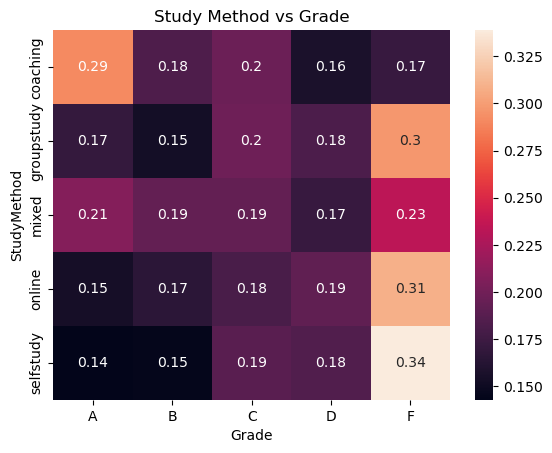

In [17]:
cross = pd.crosstab(df['StudyMethod'], df['Grade'], normalize='index')
cross = cross[grade_order]

sns.heatmap(cross, annot=True)
plt.title('Study Method vs Grade')
plt.show()

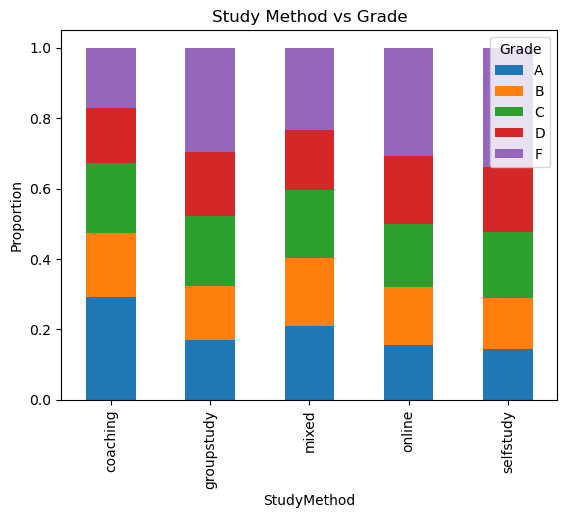

In [18]:
# SleepLevel and Grade
cross = pd.crosstab(df['StudyMethod'], df['Grade'], normalize='index')
cross = cross[grade_order]

cross.plot(kind='bar', stacked=True)
plt.title('Study Method vs Grade')
plt.ylabel('Proportion')
plt.legend(title='Grade', loc='upper right')
plt.show()

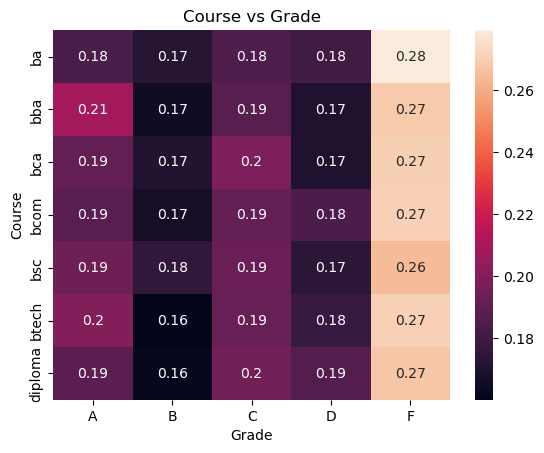

In [19]:
# Course vs Grade
cross = pd.crosstab(df['Course'], df['Grade'], normalize='index')
cross = cross[grade_order]

sns.heatmap(cross, annot=True)
plt.title('Course vs Grade')
plt.show()

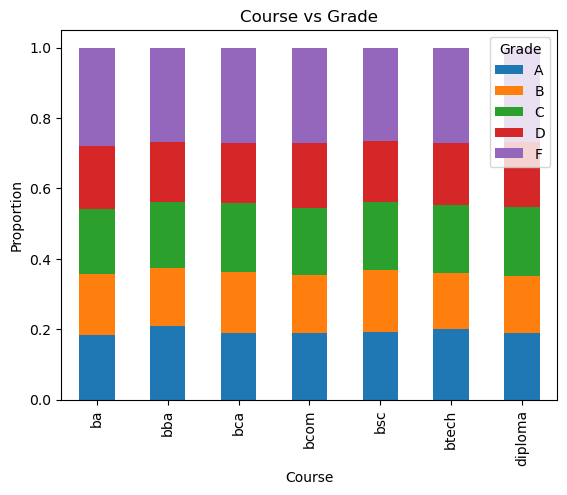

In [20]:
# SleepLevel and Grade
cross = pd.crosstab(df['Course'], df['Grade'], normalize='index')
cross = cross[grade_order]

cross.plot(kind='bar', stacked=True)
plt.title('Course vs Grade')
plt.ylabel('Proportion')
plt.legend(title='Grade', loc='upper right')
plt.show()

# StudyLevel
- Students with high study levels show a higher proportion of A and B grades.
- Low study levels are associated with higher proportions of D and F grades.
# AttendanceLevel
- Higher attendance is strongly associated with better academic performance.
- Students with low attendance tend to fall into lower grade categories.
# SleepLevel
- Students with good sleep tend to achieve better grades.
- Poor sleep is associated with lower performance levels.
# StudyMethod
- No single study method dominates across all grades, though coaching appears slightly more effective.
# Course
- Performance varies slightly across courses, but no category shows extreme differences.

# Defining Features and Target

In [21]:
# Separating Features and Target 
features = df.drop('Grade', axis=1) # all features
target = df['Grade'] # Only Grade

# Mapping Target 
- Because the target has an order: F < D < C < B < A
- Without mapping, the model treats classes as unrelated.
- With mapping the model understands the relationship and distance between grades, improving predictions, especially for middle classes like B, C, and D.
- Also for the CATBoost Model in requiered to have all the features and target as numerical or binary values

In [22]:
# mapping
grade_map = {'F':0, 'D':1, 'C':2, 'B':3, 'A':4}
target = target.map(grade_map)

In [23]:
target.head()

0    1
1    1
2    4
3    0
4    0
Name: Grade, dtype: int64

# Creating Dummies for the features

In [24]:
features_dummys = pd.get_dummies(features, drop_first=True, dtype=int)

In [25]:
features_dummys.head()

,Age,Gender_male,Gender_other,Course_bba,Course_bca,Course_bcom,Course_bsc,Course_btech,Course_diploma,InternetAccess_yes,...,FacilityRating_low,FacilityRating_medium,ExamDifficulty_hard,ExamDifficulty_moderate,StudyLevel_low,StudyLevel_medium,SleepLevel_good,SleepLevel_regular,AttendanceLevel_low,AttendanceLevel_medium
0,17,1,0,0,0,0,0,0,1,1,...,1,0,1,0,0,1,1,0,0,0
1,23,0,1,0,1,0,0,0,0,1,...,0,1,0,1,0,1,0,0,0,1
2,22,1,0,0,0,0,1,0,0,1,...,0,0,0,1,0,0,1,0,0,1
3,20,0,1,0,0,0,0,0,1,1,...,1,0,0,1,1,0,0,1,1,0
4,20,0,0,0,0,0,0,0,1,1,...,1,0,0,1,1,0,1,0,0,1


In [26]:
features_dummys.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      20000 non-null  int64
 1   Gender_male              20000 non-null  int64
 2   Gender_other             20000 non-null  int64
 3   Course_bba               20000 non-null  int64
 4   Course_bca               20000 non-null  int64
 5   Course_bcom              20000 non-null  int64
 6   Course_bsc               20000 non-null  int64
 7   Course_btech             20000 non-null  int64
 8   Course_diploma           20000 non-null  int64
 9   InternetAccess_yes       20000 non-null  int64
 10  SleepQuality_good        20000 non-null  int64
 11  SleepQuality_poor        20000 non-null  int64
 12  StudyMethod_groupstudy   20000 non-null  int64
 13  StudyMethod_mixed        20000 non-null  int64
 14  StudyMethod_online       20000 non-null  int64
 15  St

# Splitting the data and scaling some features

In [27]:
# split the data in train and test subsets    25% for test and 75% train
X_train, X_test, y_train, y_test = train_test_split(features_dummys, target, test_size=0.25, random_state=42)

In [28]:
# Scalling numerical feature 'Age' with Standar Scaler
ss = StandardScaler()
X_train_ss = X_train.copy()
X_test_ss = X_test.copy()

X_train_ss['Age'] = ss.fit_transform(X_train[['Age']])
X_test_ss['Age'] = ss.transform(X_test[['Age']])

# Features selection methods

### Feature selection with Logistic Regressor

In [29]:
# now we can select the relevant features for modeling  with logistic Regressor

# Defining Hyperparameters
lr = LogisticRegression(
    penalty='l1',
    solver='saga',         
    max_iter=5000,
    class_weight='balanced',
    random_state=0,
)

# creating selector
selector_LR = SelectFromModel(lr, threshold='median')

selector_LR.fit(X_train_ss, y_train)

# 
X_train_LR = X_train_ss.loc[:, selector_LR.get_support()]
X_test_LR = X_test_ss.loc[:, selector_LR.get_support()]

print(X_train_LR.shape)

(15000, 13)


In [30]:
X_train_LR.columns

Index(['SleepQuality_good', 'SleepQuality_poor', 'StudyMethod_groupstudy',
       'StudyMethod_mixed', 'StudyMethod_online', 'StudyMethod_selfstudy',
       'FacilityRating_low', 'FacilityRating_medium', 'StudyLevel_low',
       'StudyLevel_medium', 'SleepLevel_good', 'AttendanceLevel_low',
       'AttendanceLevel_medium'],
      dtype='object')

### Feature selection with Random Forest 

In [31]:
# now we can select the relevant features for modeling with RandomForest

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=0,
    n_jobs=-1
)

selector_RF = SelectFromModel(rf, threshold='median') 

selector_RF.fit(X_train, y_train)

X_train_RF = X_train_ss.loc[:, selector_RF.get_support()]
X_test_RF = X_test_ss.loc[:, selector_RF.get_support()]

print(X_train_RF.shape)

(15000, 13)


In [32]:
X_train_RF.columns

Index(['Age', 'Gender_male', 'Gender_other', 'Course_bca', 'Course_bcom',
       'InternetAccess_yes', 'FacilityRating_medium', 'ExamDifficulty_hard',
       'ExamDifficulty_moderate', 'StudyLevel_low', 'StudyLevel_medium',
       'AttendanceLevel_low', 'AttendanceLevel_medium'],
      dtype='object')

In [33]:
X_train_LR.columns

Index(['SleepQuality_good', 'SleepQuality_poor', 'StudyMethod_groupstudy',
       'StudyMethod_mixed', 'StudyMethod_online', 'StudyMethod_selfstudy',
       'FacilityRating_low', 'FacilityRating_medium', 'StudyLevel_low',
       'StudyLevel_medium', 'SleepLevel_good', 'AttendanceLevel_low',
       'AttendanceLevel_medium'],
      dtype='object')

- The features selected are 13 of 26 for both selectors
- But the features selected are differents in each case

# Train and Prediction using SVM prediction model

## Using all features with a few hyperparameters

In [34]:
# Training the model with all the features

svm1 = SVC(kernel='rbf')
svm1.fit(X_train_ss, y_train)

# Prediction using testing data
y_pred = svm1.predict(X_test_ss)

In [35]:
# Re Mapping again the target from number class to letters to better understand
inverse_map = {
    0: 'F',
    1: 'D',
    2: 'C',
    3: 'B',
    4: 'A'
}
y_test_labels = [inverse_map[i] for i in y_test]
y_pred_labels = [inverse_map[i] for i in y_pred]
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

           A       0.58      0.68      0.62       984
           B       0.31      0.24      0.27       822
           C       0.32      0.30      0.31       948
           D       0.26      0.13      0.17       900
           F       0.61      0.84      0.71      1346

    accuracy                           0.48      5000
   macro avg       0.42      0.44      0.42      5000
weighted avg       0.44      0.48      0.45      5000



- The SVM model achieved an overall accuracy of 48%, indicating moderate predictive performance. The model performed well in identifying extreme categories, particularly grade F, which achieved a recall of 84%, and grade A with a recall of 68%.

- However, the model struggled to accurately classify intermediate grades such as B, C, and D. In particular, grade D showed very low recall (13%), indicating that most instances of this class were misclassified.

- This behavior suggests that the model is better at distinguishing between high-performing and low-performing students, but has difficulty separating students with moderate performance levels, likely due to overlapping feature characteristics among these groups.

In [36]:
# searching better hyperparameters for the SVM ----------------------------Dont run again, much time calculating
# param_grid = {
#     'C': [1, 5, 10],
#     'kernel': ['poly'],
#     'degree': [2, 3],
#     'gamma': ['scale'],
# }

# grid = GridSearchCV(SVC(), param_grid, cv=3)
# grid.fit(X_train_ss, y_train)

# print("Best parameters:", grid.best_params_)
# print("Best score:", grid.best_score_)

Best parameters: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
Best score: 0.4782

# Implementing the recommended hyperparameters

## Using all the features

In [37]:
# Training the model with all the features
svm2 = SVC(kernel='poly', gamma='scale', degree=2, C=1, class_weight='balanced')
svm2.fit(X_train_ss, y_train)

# Prediction using testing data
y_pred_svm = svm2.predict(X_test_ss)

In [38]:
inverse_map = {
    0: 'F',
    1: 'D',
    2: 'C',
    3: 'B',
    4: 'A'
}
y_test_labels = [inverse_map[i] for i in y_test]
y_pred_labels = [inverse_map[i] for i in y_pred_svm]
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

           A       0.59      0.66      0.62       984
           B       0.31      0.36      0.34       822
           C       0.34      0.23      0.27       948
           D       0.31      0.34      0.32       900
           F       0.70      0.69      0.69      1346

    accuracy                           0.48      5000
   macro avg       0.45      0.46      0.45      5000
weighted avg       0.48      0.48      0.47      5000



- Applying class weighting and additional parameters significantly improved recall for underrepresented classes (especially class D), resulting in a more balanced model as reflected in higher macro average scores.

## Using features selected with Logistic Regressor 

In [39]:
# searching better hyperparameters for the SVM ----------------------------Dont run again, much time calculating
#param_grid = {
#    'C': [1, 5, 10],
#    'kernel': ['poly'],
#     'degree': [2, 3],
#     'gamma': ['scale']
# }

# grid = GridSearchCV(SVC(), param_grid, cv=3)
# grid.fit(X_train_LR, y_train)

# print("Best parameters:", grid.best_params_)
# print("Best score:", grid.best_score_)

Best parameters: {'C': 5, 'degree': 2, 'gamma': '2', 'kernel': 'poly'}
Best score: 0.4678

In [40]:
# Training the model with addiotional recommended parameters and features selected with Logistic regressor

svm_LR = SVC(kernel='poly', gamma=2, degree=2, C=5, class_weight='balanced')
svm_LR.fit(X_train_LR, y_train)

# Prediction using testing data
y_pred_svm_LR = svm_LR.predict(X_test_LR)

In [41]:
inverse_map = {
    0: 'F',
    1: 'D',
    2: 'C',
    3: 'B',
    4: 'A'
}
y_test_labels = [inverse_map[i] for i in y_test]
y_pred_labels = [inverse_map[i] for i in y_pred_svm_LR]
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

           A       0.59      0.70      0.64       984
           B       0.33      0.35      0.34       822
           C       0.33      0.20      0.25       948
           D       0.30      0.34      0.32       900
           F       0.69      0.70      0.70      1346

    accuracy                           0.48      5000
   macro avg       0.45      0.46      0.45      5000
weighted avg       0.47      0.48      0.47      5000



## Using features selected with Random Forest 

In [42]:
# searching better hyperparameters for the SVM ----------------------------Dont run again, much time calculating
# param_grid = {
#     'C': [1, 5, 10],
#     'kernel': ['poly'],
#     'degree': [2, 3],
#     'gamma': ['scale'],
#     'class_weight': [None, 'balanced']
# }

# grid = GridSearchCV(SVC(), param_grid, cv=3)
# grid.fit(X_train_RF, y_train)

# print("Best parameters:", grid.best_params_)
# print("Best score:", grid.best_score_)

Best parameters: {'C': 5, 'class_weight': None, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}
Best score: 0.4496

In [43]:
# Training the model with addiotional recommended parameters and features selected with Random Forest 

svm_RF = SVC(kernel='poly', gamma='scale', degree=3, C=5, class_weight='balanced')
svm_RF.fit(X_train_RF, y_train)

# Prediction using testing data
y_pred_svm_RF = svm_RF.predict(X_test_RF)

In [44]:
inverse_map = {
    0: 'F',
    1: 'D',
    2: 'C',
    3: 'B',
    4: 'A'
}
y_test_labels = [inverse_map[i] for i in y_test]
y_pred_labels = [inverse_map[i] for i in y_pred_svm_RF]
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

           A       0.53      0.65      0.58       984
           B       0.26      0.30      0.28       822
           C       0.29      0.14      0.19       948
           D       0.26      0.22      0.24       900
           F       0.59      0.73      0.65      1346

    accuracy                           0.44      5000
   macro avg       0.39      0.41      0.39      5000
weighted avg       0.41      0.44      0.42      5000



# Train and Prediction using CatBoost model

## Using all the features

In [45]:
# searching better hyperparameters for the CatBoost model ---------------------------Dont run again, much time calculating
# param_grid = {
#     'iterations': [300, 500],
#     'depth': [6, 8],
#     'learning_rate': [0.03, 0.1],
#     'l2_leaf_reg': [3, 5]
# }

# grid = GridSearchCV(
#     estimator=cb_model,
#     param_grid=param_grid,
#     cv=3,
#     scoring='accuracy',
#     n_jobs=-1
# )

# grid.fit(X_train, y_train)
# print("Best parameters:", grid.best_params_)  
# print("Best score:", grid.best_score_)

Best parameters: {'depth': 6, 'iterations': 300, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
Best score: 0.47946666666666665

In [46]:
# Training the model with addiotional recommended parameters and all the features  loss_function='MultiClass',random_seed=42

cb_model = CatBoostClassifier(iterations=300,depth=6,learning_rate=0.03,l2_leaf_reg = 3,verbose=0 )

cb_model.fit(X_train_ss, y_train)
y_pred_cb = cb_model.predict(X_test_ss)

In [47]:
inverse_map = {
    0: 'F',
    1: 'D',
    2: 'C',
    3: 'B',
    4: 'A'
}

y_pred_cb = y_pred_cb.flatten()

y_test_labels = [inverse_map[i] for i in y_test]
y_pred_labels = [inverse_map[i] for i in y_pred_cb]
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

           A       0.58      0.74      0.65       984
           B       0.34      0.21      0.26       822
           C       0.32      0.34      0.33       948
           D       0.26      0.12      0.17       900
           F       0.62      0.82      0.71      1346

    accuracy                           0.49      5000
   macro avg       0.42      0.45      0.42      5000
weighted avg       0.44      0.49      0.45      5000



## Using features selected with Logistic Regressor 

In [48]:
# Training the model with addiotional recommended parameters and features selected with Logistic regressor
cb_LR = CatBoostClassifier(iterations=300,depth=6,learning_rate=0.03,l2_leaf_reg = 3,verbose=0 )

cb_LR.fit(X_train_LR, y_train)
y_pred_cb_LR = cb_LR.predict(X_test_LR)

In [49]:
inverse_map = {
    0: 'F',
    1: 'D',
    2: 'C',
    3: 'B',
    4: 'A'
}

y_pred_cb_LR = y_pred_cb_LR.flatten()

# Convert NumPy arrays to Python integers before using as dictionary keys
y_test_labels = [inverse_map[int(i)] for i in y_test]
y_pred_labels = [inverse_map[int(i)] for i in y_pred_cb_LR]
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

           A       0.58      0.72      0.65       984
           B       0.33      0.23      0.27       822
           C       0.33      0.35      0.34       948
           D       0.34      0.17      0.23       900
           F       0.64      0.82      0.72      1346

    accuracy                           0.50      5000
   macro avg       0.44      0.46      0.44      5000
weighted avg       0.46      0.50      0.47      5000



## Using features selected with Random Forest 

In [50]:
# Training the model with addiotional recommended parameters and features selected with Random Forest
cb_RF = CatBoostClassifier(iterations=300,depth=6,learning_rate=0.03,l2_leaf_reg = 3,verbose=0 )

cb_RF.fit(X_train_RF, y_train)
y_pred_cb_RF = cb_RF.predict(X_test_RF)

In [51]:
inverse_map = {
    0: 'F',
    1: 'D',
    2: 'C',
    3: 'B',
    4: 'A'
}

y_pred_cb_RF = y_pred_cb_RF.flatten()

y_test_labels = [inverse_map[i] for i in y_test]
y_pred_labels = [inverse_map[i] for i in y_pred_cb_RF]
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

           A       0.52      0.66      0.58       984
           B       0.27      0.17      0.21       822
           C       0.28      0.28      0.28       948
           D       0.27      0.11      0.16       900
           F       0.56      0.81      0.66      1346

    accuracy                           0.45      5000
   macro avg       0.38      0.41      0.38      5000
weighted avg       0.40      0.45      0.41      5000



# Confusion matrix and Precision recall of the best model

- The best model is CatBoost with feature selection using Logistic Regresor

In [52]:
# Features selected 
X_train_LR.columns

Index(['SleepQuality_good', 'SleepQuality_poor', 'StudyMethod_groupstudy',
       'StudyMethod_mixed', 'StudyMethod_online', 'StudyMethod_selfstudy',
       'FacilityRating_low', 'FacilityRating_medium', 'StudyLevel_low',
       'StudyLevel_medium', 'SleepLevel_good', 'AttendanceLevel_low',
       'AttendanceLevel_medium'],
      dtype='object')

In [53]:
# Precision recall from best model
inverse_map = {
    0: 'F',
    1: 'D',
    2: 'C',
    3: 'B',
    4: 'A'
}

y_pred_cb_LR = y_pred_cb_LR.flatten()

y_test_labels = [inverse_map[int(i)] for i in y_test]
y_pred_labels = [inverse_map[int(i)] for i in y_pred_cb_LR]
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

           A       0.58      0.72      0.65       984
           B       0.33      0.23      0.27       822
           C       0.33      0.35      0.34       948
           D       0.34      0.17      0.23       900
           F       0.64      0.82      0.72      1346

    accuracy                           0.50      5000
   macro avg       0.44      0.46      0.44      5000
weighted avg       0.46      0.50      0.47      5000



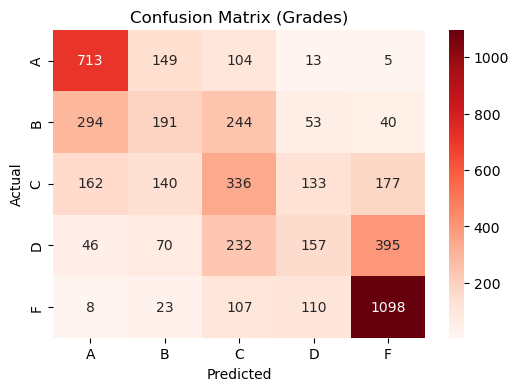

In [54]:
# Confusion matrix of best model
cm = confusion_matrix(y_test_labels, y_pred_labels)

labels = ['A','B', 'C', 'D', 'F']

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Grades)')
plt.show()

- The best model predicts extremes well (A and F), but still struggling with middle classes (B, C, D).
- Despite testing multiple models (SVM, Random Forest, XGBoost, CatBoost, Naive Bayes), performance remained stable around 0.48~0.5 accuracy. This suggests that the limitation is not model-related but due to overlapping feature distributions between intermediate classes.

# Train and Prediction using the best model - with reduced number of classes

In [55]:
# Mapping again the grade to reduce number of classes from 5 to just 3
target1 = df['Grade']
grade_map = {
    'A': 'High',
    'B': 'High',
    'C': 'Medium',
    'D': 'Low',
    'F': 'Low'
}

target1 = target1.map(grade_map)

In [72]:
target1.head()

0     Low
1     Low
2    High
3     Low
4     Low
Name: Grade, dtype: object

In [57]:
target1.info()

<class 'pandas.core.series.Series'>
RangeIndex: 20000 entries, 0 to 19999
Series name: Grade
Non-Null Count  Dtype 
--------------  ----- 
20000 non-null  object
dtypes: object(1)
memory usage: 156.4+ KB


In [58]:
# Creating subsets of the data for training and testing     100 ---> 75% to train data  and 25% to testing data

X1_train, X1_test, y1_train, y1_test = train_test_split(features_dummys, target1, test_size=0.25, random_state=42)


In [59]:
# Scalling numerical feature 'Age' with Standar Scaler
ss = StandardScaler()
X1_train_ss = X1_train.copy()
X1_test_ss = X1_test.copy()

X1_train_ss['Age'] = ss.fit_transform(X1_train[['Age']])
X1_test_ss['Age'] = ss.transform(X1_test[['Age']])

In [60]:
# now we can select the relevant features for modeling  with logistic Regressor

# Defining Hyperparameters
lr = LogisticRegression(
    penalty='l1',
    solver='saga',         
    max_iter=5000,
    class_weight='balanced',
    random_state=0,
)

# creating selector
selector1_LR = SelectFromModel(lr, threshold='median')

selector1_LR.fit(X1_train_ss, y1_train)

# 
X1_train_LR = X1_train_ss.loc[:, selector1_LR.get_support()]
X1_test_LR = X1_test_ss.loc[:, selector1_LR.get_support()]

print(X1_train_LR.shape)

(15000, 13)


In [61]:
X1_train_LR.columns

Index(['SleepQuality_good', 'SleepQuality_poor', 'StudyMethod_groupstudy',
       'StudyMethod_mixed', 'StudyMethod_online', 'StudyMethod_selfstudy',
       'FacilityRating_low', 'FacilityRating_medium', 'StudyLevel_low',
       'StudyLevel_medium', 'SleepLevel_good', 'AttendanceLevel_low',
       'AttendanceLevel_medium'],
      dtype='object')

In [62]:
# cb = CatBoostClassifier(
#     loss_function='MultiClass',
#     random_seed=42,
#     verbose=0
# )
# param_grid = {
#     'iterations': [500, 1000],
#     'depth': [6, 8, 10],
#     'learning_rate': [0.01, 0.03, 0.05],
#     'l2_leaf_reg': [1, 3, 5],
# }

# grid = GridSearchCV(
#     estimator=cb,
#     param_grid=param_grid,
#     cv=3,
#     scoring='accuracy',
#     n_jobs=-1
# )

# grid.fit(X1_train_LR, y1_train)

In [67]:
# print("Best params:", grid.best_params_)
# print("Best score:", grid.best_score_)

Best params: {'depth': 6, 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.01}
Best score: 0.7002

In [64]:
# Training the model with addiotional recommended parameters and features selected with Logistic regressor
cb1_LR = CatBoostClassifier(iterations=500,
                            depth=8,
                            learning_rate=0.01,
                            l2_leaf_reg = 5,
                            verbose=0 ,
                            class_weights = [1.0, 1.0, 2.0])

cb1_LR.fit(X1_train_LR, y1_train)
y1_pred_cb_LR = cb1_LR.predict(X1_test_LR)

In [65]:
y1_pred_cb_LR = y1_pred_cb_LR.flatten()

print(classification_report(y1_test, y1_pred_cb_LR))

              precision    recall  f1-score   support

        High       0.79      0.69      0.73      1806
         Low       0.84      0.73      0.78      2246
      Medium       0.32      0.50      0.39       948

    accuracy                           0.67      5000
   macro avg       0.65      0.64      0.64      5000
weighted avg       0.72      0.67      0.69      5000



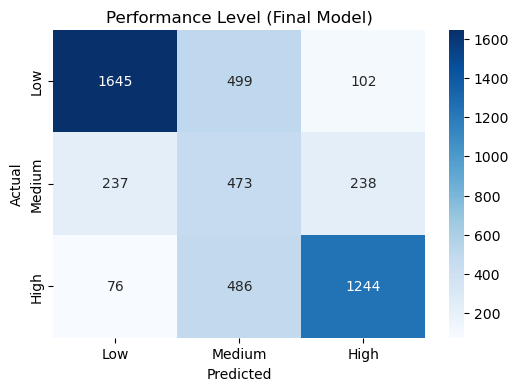

In [70]:
# Define label order 
labels = ['Low', 'Medium', 'High']

cm = confusion_matrix(y1_test, y1_pred_cb_LR, labels=labels)

plt.figure(figsize=(6,4))

sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Performance Level (Final Model)')
plt.show()

- Grouping the target variable into three ordinal categories significantly improved model performance, increasing accuracy from approximately 0.50 to 0.67. This suggests that the original 5-class problem contained high class overlap, particularly among intermediate categories.
- Hyperparameter tuning is important because it directly controls how a model learns from the data, influencing its complexity, generalization ability, and overall performance.
- By adjusting parameters such as learning rate, depth, or regularization strength, we can reduce overfitting or underfitting and help the model better capture patterns in the data.
- Proper tuning often leads to more stable and accurate predictions, as it allows the model to reach its optimal configuration for a specific dataset rather than relying on default settings.